In [37]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import scipy.linalg as la
import matplotlib.pyplot as plt
from scripts.constants import *
from scripts.hamiltonian_v2 import *
from scripts.self_consistency_v2 import *


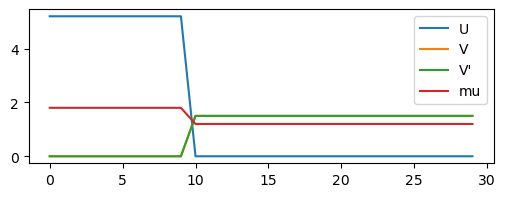

In [38]:
widthN = 10
widthP = 20

X, Y = widthN+widthP, 100
lattice = Lattice(X, Y)
t = 1
T = 0.02
muN = 1.2 * t
muP = 1.8 * t
mu = np.zeros(lattice.X)
mu[widthN:] = muN
mu[:widthN] = muP

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthN:] = 0

V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V[:widthN] = 0 

V_prime = V0 * np.ones(lattice.X)
V_prime[:widthN] = 0

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, label="U")
if V is not None:
    plt.plot(V, label="V")
if V_prime is not None:
    plt.plot(V_prime, label="V'")
plt.plot(mu, label='mu')
plt.legend()

In [39]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=None, V=V, F0_init=0.01, F_init=[0.01, -0.01, 0.01j, -0.01j])


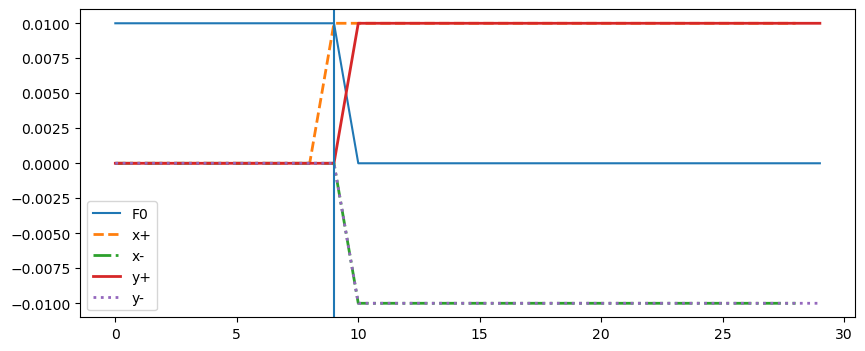

In [40]:
plt.figure(figsize=(10,4))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(9)

In [41]:
print(is_hermitian(H.build_Hk(PI/4)))
print(is_hermitian(H.matrix))

True
True


In [42]:
i = 0
gap0 = np.array([0.1 + 0.2j])
block = np.zeros((4, 4), dtype=np.complex128)
block[0, 3] = -gap0[i]
block[1, 2] = gap0[i]
block[2, 1] = gap0[i].conj()
block[3, 0] = (-gap0[i]).conj()

print(block)

block = np.zeros((4, 4), dtype=np.complex128)
block[:2, 2:] = -1j * gap0 * s2
block[2:, :2] = (-1j * gap0 * s2).conj().T

print(block)


[[ 0. +0.j   0. +0.j   0. +0.j  -0.1-0.2j]
 [ 0. +0.j   0. +0.j   0.1+0.2j  0. +0.j ]
 [ 0. +0.j   0.1-0.2j  0. +0.j   0. +0.j ]
 [-0.1+0.2j  0. +0.j   0. +0.j   0. +0.j ]]
[[ 0. +0.j   0. +0.j   0. +0.j  -0.1-0.2j]
 [ 0. +0.j   0. +0.j   0.1+0.2j  0. +0.j ]
 [ 0. -0.j   0.1-0.2j  0. +0.j   0. +0.j ]
 [-0.1+0.2j  0. -0.j   0. +0.j   0. +0.j ]]


In [43]:
bdg_self_consistency(H, temperature=0.0, maxiter=100, atol=1e-4, rtol=0.1, verbose=True) # CHECK: triplet y- and singlet BCS


Iteration 1:
F0:
Absolute error: 0.1415783929045176
Relative error: 36803497437.11388
Average_old: (0.0033333333333333335+0j)
Average_new: (0.022630632586369426+0j)
F_xplus:
Absolute error: 0.05605638029300165
Relative error: 49261249362.325
Average_old: (0.006896551724137931+0j)
Average_new: (0.005245690773365026+0j)
F_xmin:
Absolute error: 0.06542555129055964
Relative error: 59454623691.43408
Average_old: (-0.006551724137931035+0j)
Average_new: (-0.01675521032533951+0j)
F_yplus:
Absolute error: 0.08625961714025394
Relative error: 54397917958.47437
Average_old: 0.006666666666666667j
Average_new: (-0.008167087520502315+0.017414654975656464j)
F_ymin:
Absolute error: 0.08625961714025394
Relative error: 54397917958.47437
Average_old: -0.006666666666666667j
Average_new: (-0.008167087520502315-0.017414654975656464j)
Fuu_xplus:
Absolute error: 2.9158525110831644e-17
Relative error: 2.9158525110831643e-05
Average_old: 0j
Average_new: (2.1130564477882306e-18+0j)
Fuu_xmin:
Absolute error: 3.713

In [44]:
F0, F_xplus, F_xmin, F_yplus, F_ymin,\
Fuu_xplus, Fuu_xmin, Fuu_yplus, Fuu_ymin,\
Fdd_xplus, Fdd_xmin, Fdd_yplus, Fdd_ymin= H.get_correlations()

In [45]:
Nx = F_yplus.shape[0]  # number of x sites

Fx_p = np.zeros(Nx, dtype=complex)
Fx_m = np.zeros(Nx, dtype=complex)
Fx_p[:-1] = F_xplus      # site i gets bond (i,i+1)
Fx_m[1:]  = F_xmin       # site i gets bond (i,i-1).T

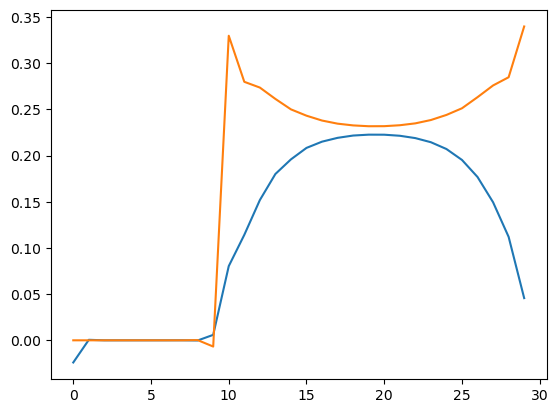

In [46]:
plt.plot(np.real(Fx_p - Fx_m)/2)
plt.plot(np.imag(F_yplus - F_ymin)/2) # TEST: UPDATE ONLY THE SC PART 
# plt.plot(np.real(F0))
# plt.plot(F0)
# plt.plot((Fx_p + Fx_m - F_yplus - F_ymin)/4)